# Data Prep for Time to Injury Forecasting DeepHit Model

This script replicates this paper https://arxiv.org/html/2601.19479v1 that builds a time-to-injury forecasting model based on the DeebHit model and uses SoccerMon data

In [29]:
from subjective_metrics_pipeline import PlayerMetricsPipeline
from subjective_metrics_eda import SubjectiveMetricsEDA

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler

## 1. Subjective Data Prep

In [30]:
# 1. Your exact, verified file paths
file_mapping = {
    'data/subjective/training-load/atl.csv': 'ATL',
    'data/subjective/training-load/weekly_load.csv': 'Weekly load',
    'data/subjective/training-load/monotony.csv': 'Monotony',
    'data/subjective/training-load/strain.csv': 'Strain',
    'data/subjective/training-load/acwr.csv': 'ACWR',
    'data/subjective/training-load/ctl28.csv': 'CTL28',
    'data/subjective/training-load/ctl42.csv': 'CTL42',
    'data/subjective/wellness/fatigue.csv': 'Fatigue',
    'data/subjective/wellness/mood.csv': 'Mood',
    'data/subjective/wellness/readiness.csv': 'Readiness',
    'data/subjective/wellness/sleep_duration.csv': 'Sleep duration',
    'data/subjective/wellness/soreness.csv': 'Soreness',
    'data/subjective/wellness/stress.csv': 'Stress'
}

# 3. Instantiate WITH the mapping dictionary explicitly
pipeline = PlayerMetricsPipeline(mapping=file_mapping)
final_df = pipeline.run()

# Display the first few rows
final_df.head()

🚀 Starting pipeline execution...

  ✅ Processed ATL: Generated 36550 rows.
  ✅ Processed Weekly load: Generated 36550 rows.
  ✅ Processed Monotony: Generated 36550 rows.
  ✅ Processed Strain: Generated 36550 rows.
  ✅ Processed ACWR: Generated 36550 rows.
  ✅ Processed CTL28: Generated 36550 rows.
  ✅ Processed CTL42: Generated 36550 rows.
  ✅ Processed Fatigue: Generated 36550 rows.
  ✅ Processed Mood: Generated 36550 rows.
  ✅ Processed Readiness: Generated 36550 rows.
  ✅ Processed Sleep duration: Generated 36550 rows.
  ✅ Processed Soreness: Generated 36550 rows.
  ✅ Processed Stress: Generated 36550 rows.

⏳ Formatting final schema. Total rows merged: 36550...
🎉 Pipeline complete! Final dataset shape: (36550, 15)


,player_name,date,ATL,Weekly load,Monotony,Strain,ACWR,CTL28,CTL42,Fatigue,Mood,Readiness,Sleep duration,Soreness,Stress
0,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 EDA

2026-05-17 20:55:11,121 - INFO - Analyzing missing data...


Starting Sports Data EDA Suite...
----------------------------------------


c:\Users\GARETHE\Projects\Personal-Website\Injury Prediction\subjective_metrics_eda.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="mako")


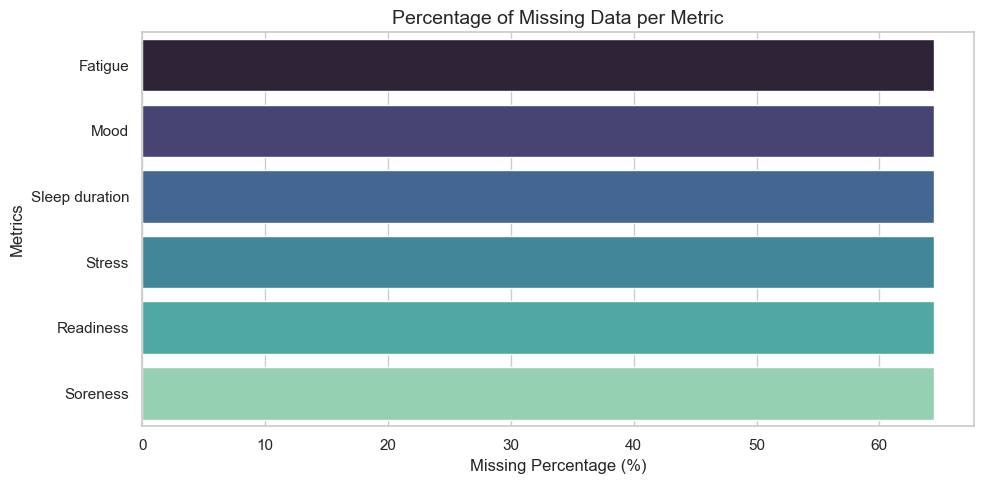

2026-05-17 20:55:11,259 - INFO - Plotting distributions and univariate outliers...


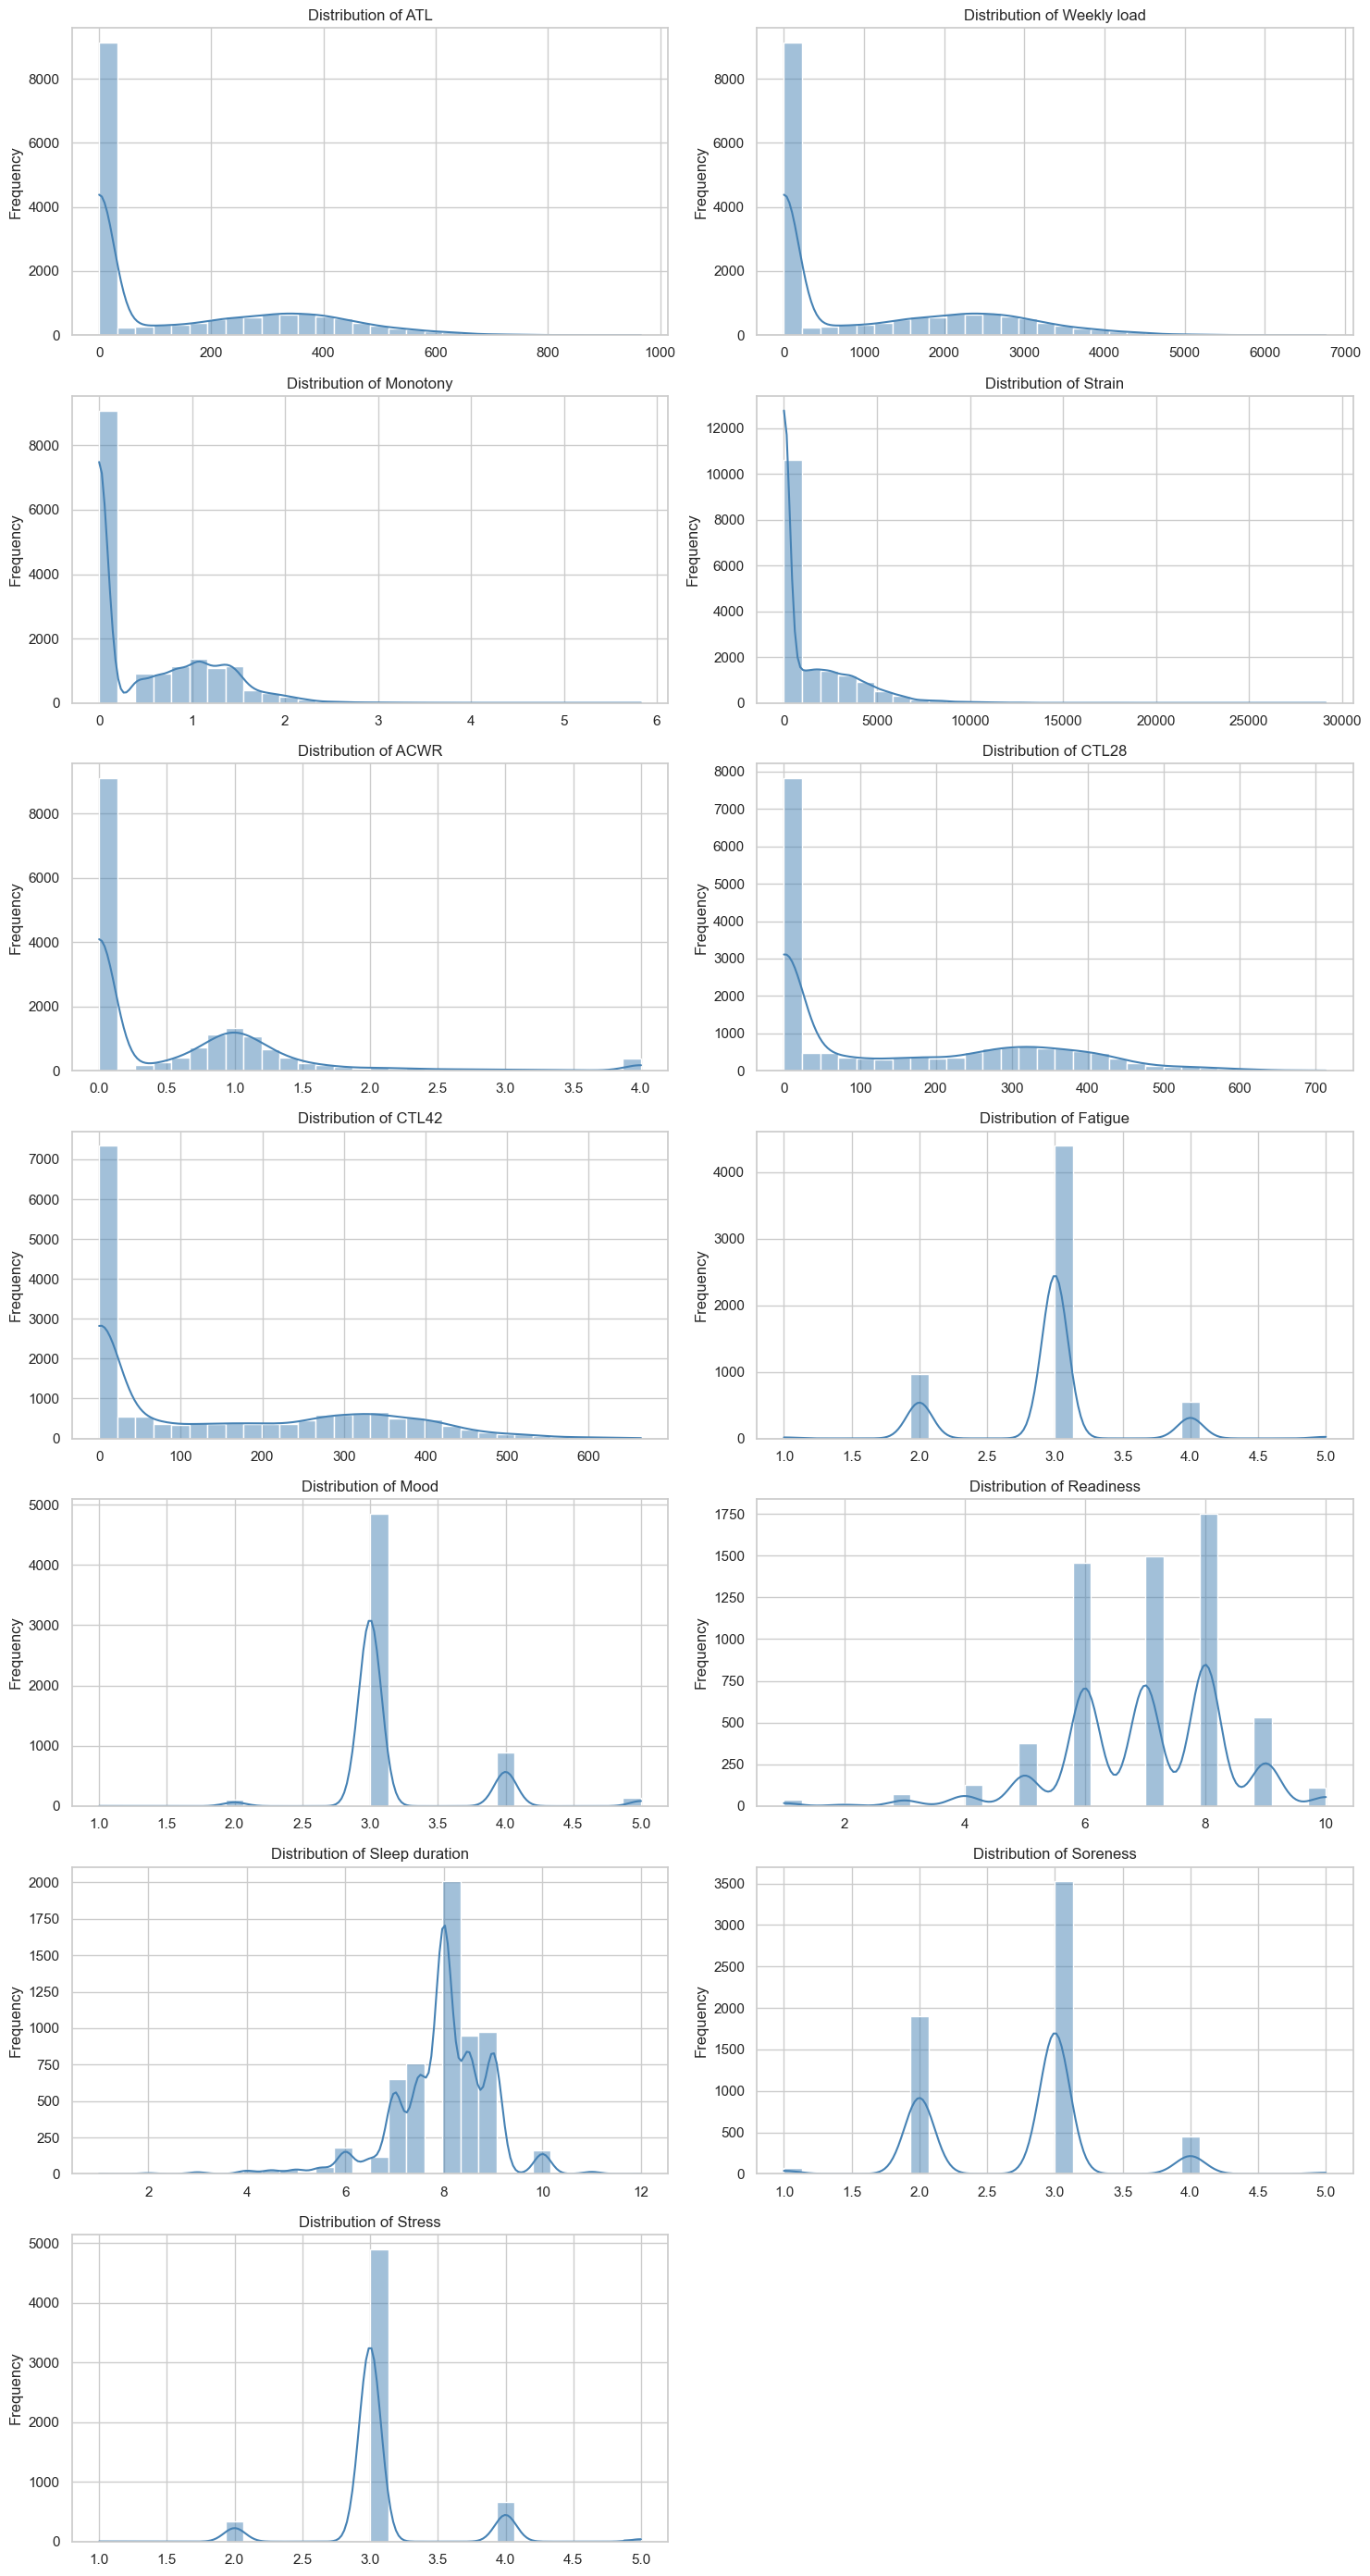

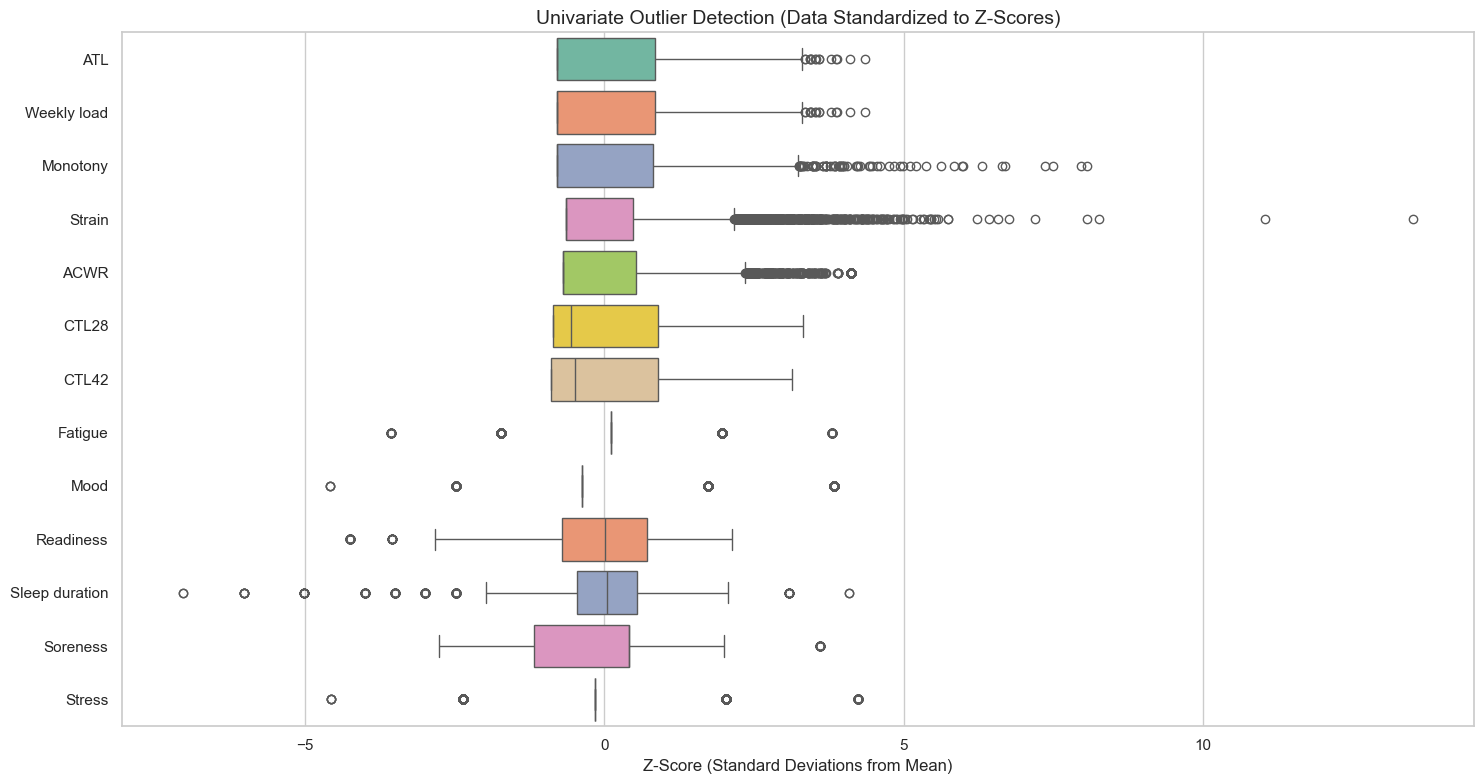

2026-05-17 20:55:15,459 - INFO - Generating correlation matrix...


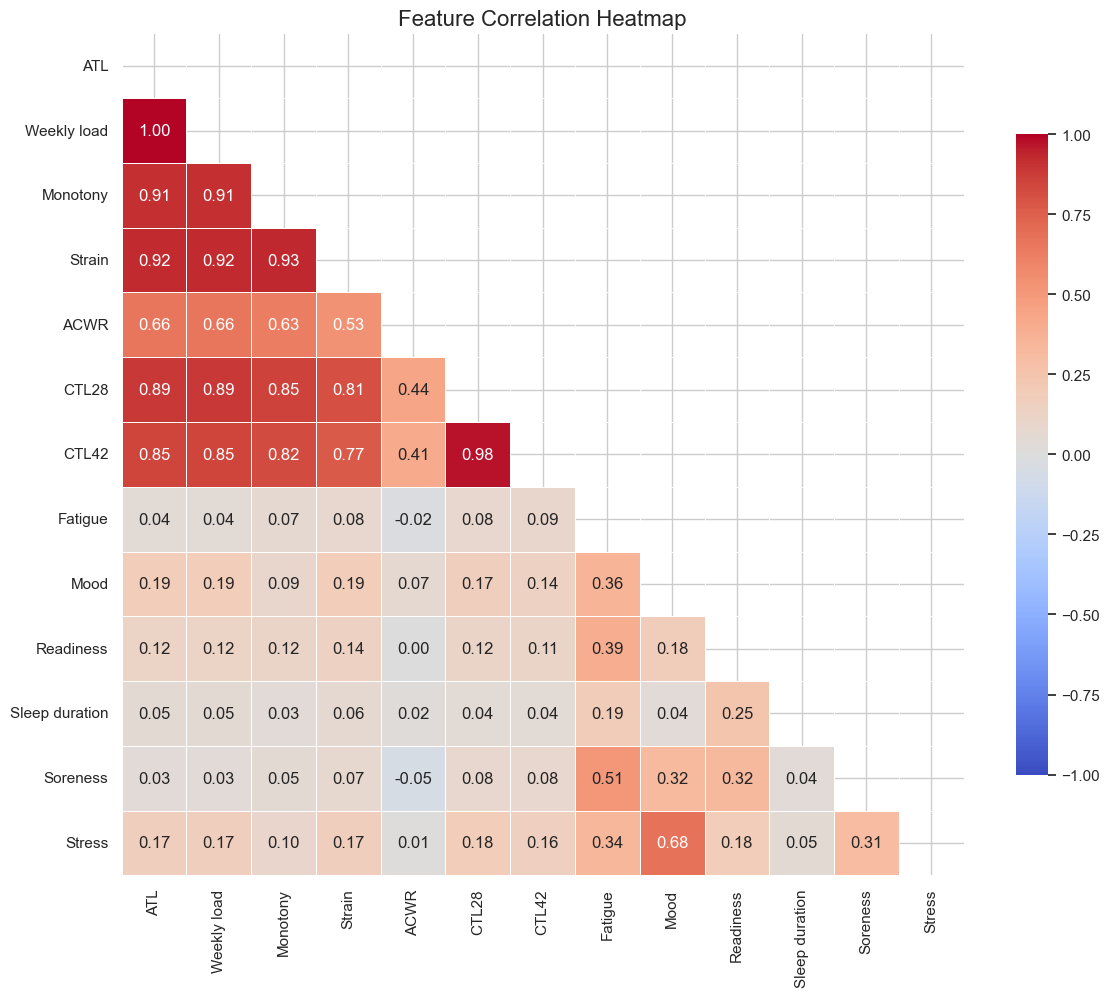

2026-05-17 20:55:16,365 - INFO - Plotting longitudinal trends for ['ATL', 'Readiness', 'Fatigue']...


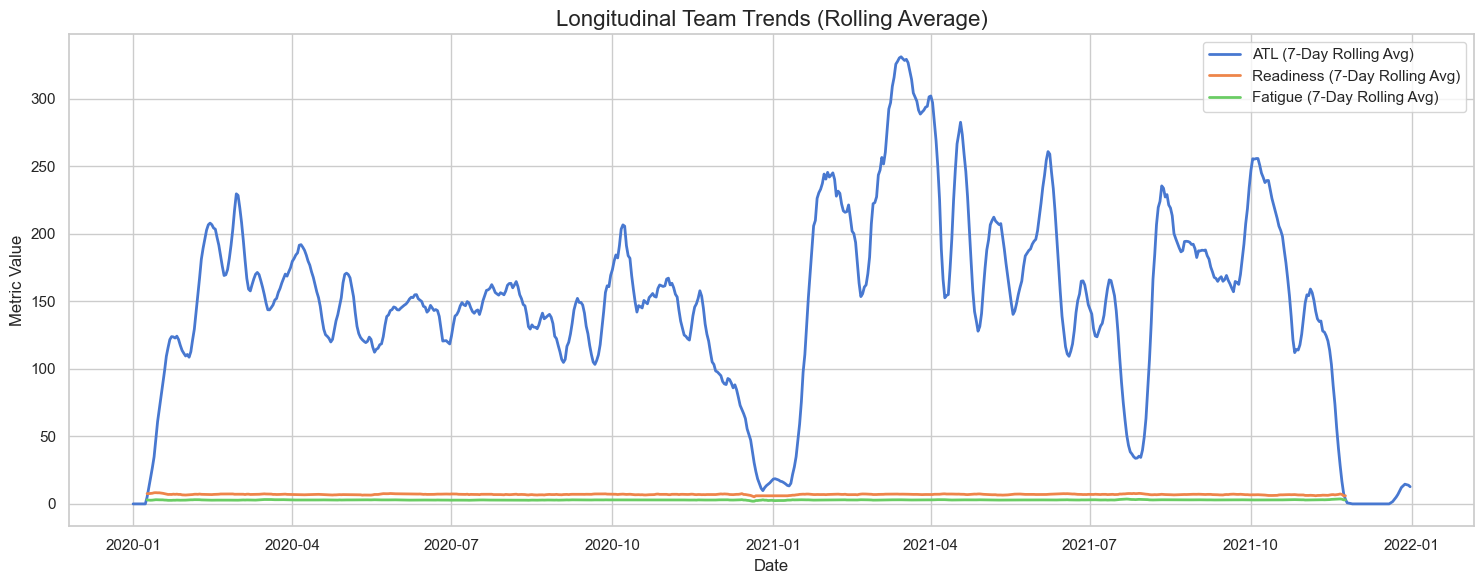

2026-05-17 20:55:16,657 - INFO - Running Isolation Forest for multivariate anomaly detection...
2026-05-17 20:55:16,880 - INFO - Detected 179 multivariate anomalies.


----------------------------------------
EDA Complete.


,player_name,date,ATL,Weekly load,Monotony,Strain,ACWR,CTL28,CTL42,Fatigue,Mood,Readiness,Sleep duration,Soreness,Stress,anomaly_score
20344,TeamB-08e35b7b-d2ad-411f-a0de-4e663f14c3c3,2021-08-30,34.29,240.0,0.41,98.4,4.001167,8.57,5.71,4.0,5.0,7.0,8.0,2.0,2.0,-1
20345,TeamB-08e35b7b-d2ad-411f-a0de-4e663f14c3c3,2021-08-31,34.29,240.0,0.41,98.4,4.001167,8.57,5.71,2.0,3.0,7.0,8.0,2.0,3.0,-1
20348,TeamB-08e35b7b-d2ad-411f-a0de-4e663f14c3c3,2021-09-03,34.29,240.0,0.41,98.4,4.001167,8.57,5.71,4.0,3.0,7.0,9.0,2.0,3.0,-1
20876,TeamB-29c5271b-5c46-455e-91ea-da2abfa8ff3c,2021-02-12,461.43,3230.0,0.97,3133.1,1.275408,361.79,241.19,1.0,3.0,1.0,7.5,1.0,4.0,-1
21086,TeamB-29c5271b-5c46-455e-91ea-da2abfa8ff3c,2021-09-10,101.43,710.0,0.52,369.2,1.135961,89.29,151.43,1.0,3.0,3.0,4.0,1.0,3.0,-1


(179, 16)

In [31]:
# using team B only
team_b_df = final_df[final_df["player_name"].str.contains("TeamB", na=False)]

# Assuming 'final_df' is the dataframe outputted from your pipeline in the previous step:

eda_pipeline = SubjectiveMetricsEDA(df=team_b_df)
multivariate_anomalies = eda_pipeline.run_all()

# You can inspect the specific abnormal dates/players identified by the Isolation Forest:
display(multivariate_anomalies.head())
display(multivariate_anomalies.shape)

C:\Users\GARETHE\AppData\Local\Temp\ipykernel_37820\965451567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compliance.values, y=compliance.index, palette="flare")


Running Missingness Diagnostics...



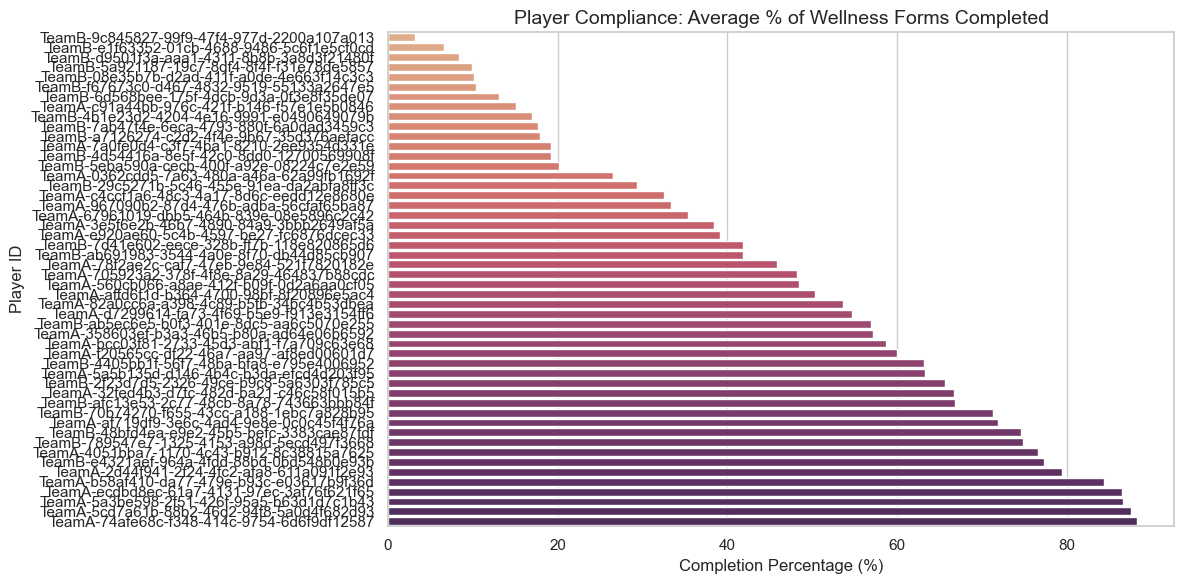

<Figure size 1200x600 with 0 Axes>

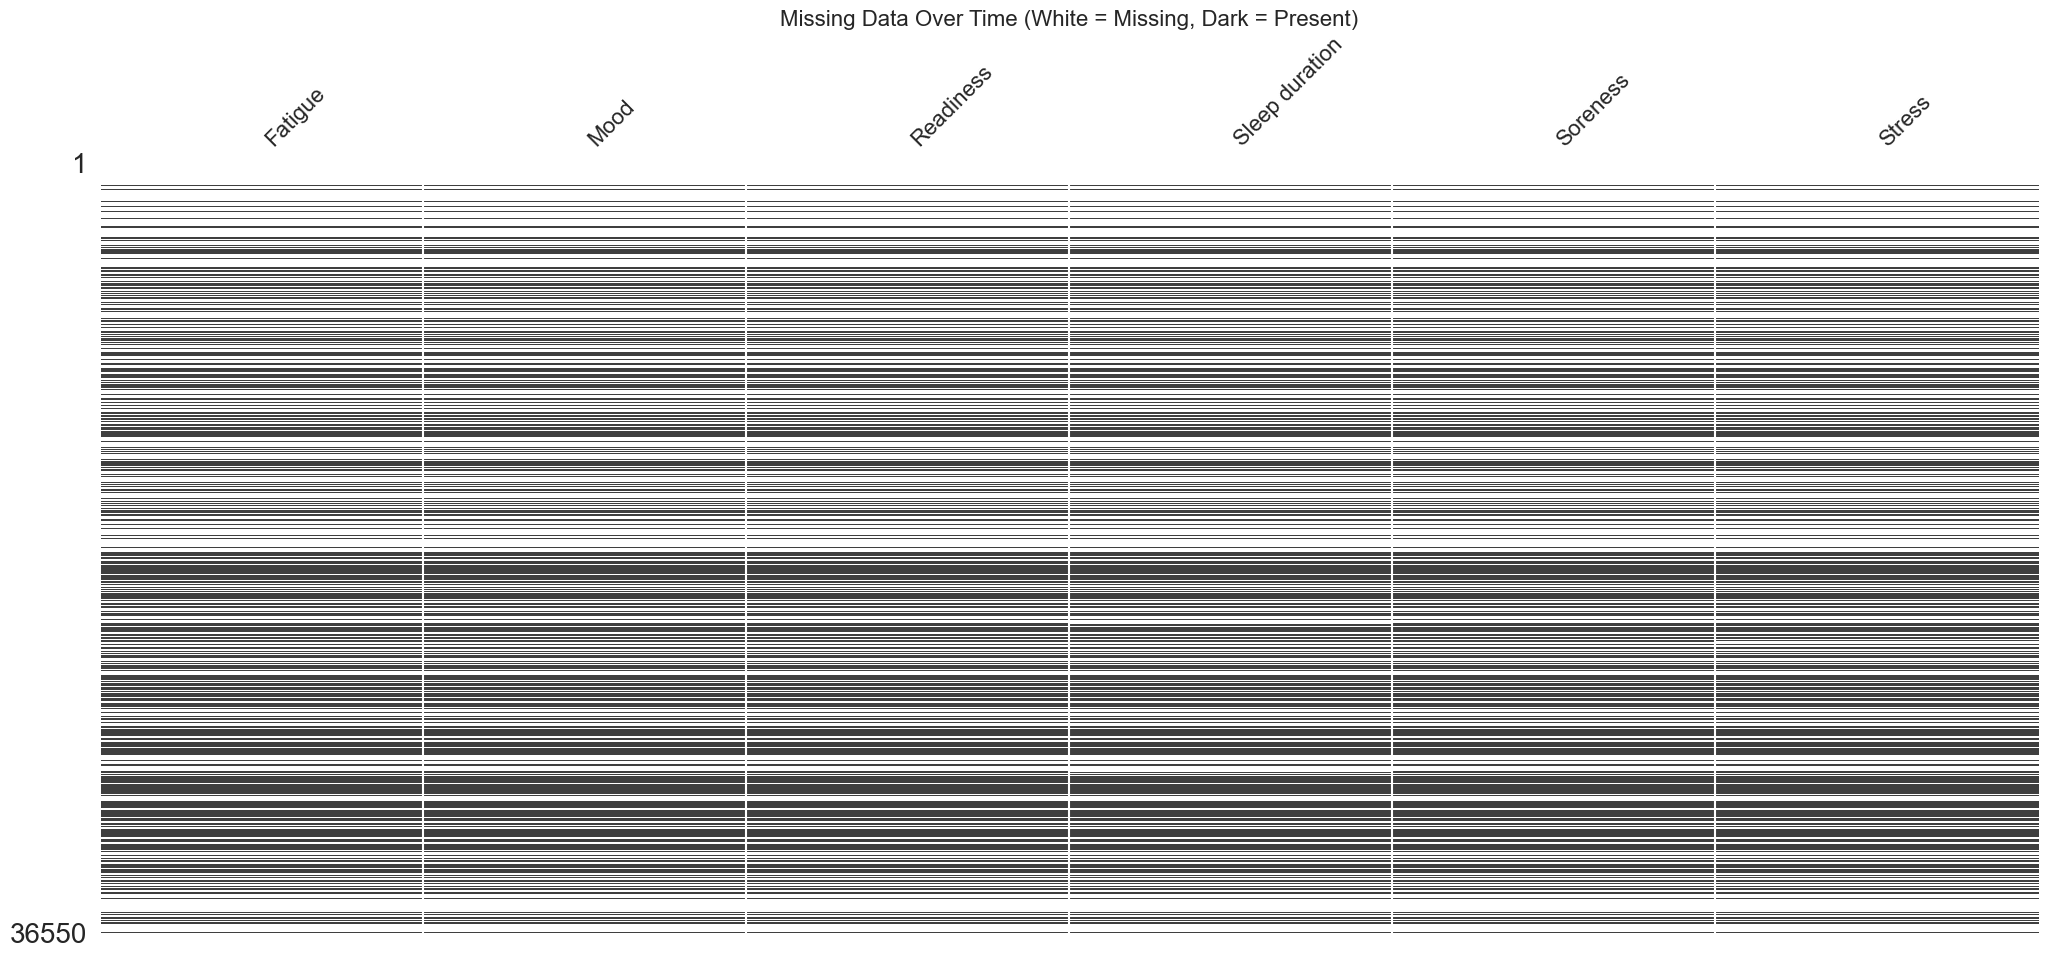

In [32]:
def diagnose_missingness(df):
    print("Running Missingness Diagnostics...\n")
    
    subjective_cols = ['Fatigue', 'Mood', 'Readiness', 'Sleep duration', 'Soreness', 'Stress']
    
    # 1. Player Compliance Check (Bar Chart)
    compliance = df.groupby('player_name')[subjective_cols].apply(lambda x: x.notnull().mean().mean() * 100).sort_values()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=compliance.values, y=compliance.index, palette="flare")
    plt.title("Player Compliance: Average % of Wellness Forms Completed", fontsize=14)
    plt.xlabel("Completion Percentage (%)")
    plt.ylabel("Player ID")
    plt.tight_layout()
    plt.show()

    # 2. Temporal Missingness Heatmap     
    # Ensure date is a datetime object first
    df_sorted = df.copy()
    df_sorted['date'] = pd.to_datetime(df_sorted['date'])
    
    # Sort chronologically, set as index, and convert to PeriodIndex
    df_time_indexed = df_sorted.sort_values('date').set_index('date')
    df_time_indexed.index = df_time_indexed.index.to_period('D')
    
    plt.figure(figsize=(12, 6))
    msno.matrix(df_time_indexed[subjective_cols], sparkline=False)
    plt.title("Missing Data Over Time (White = Missing, Dark = Present)", fontsize=16)
    plt.show()

# Run it on your dataframe
diagnose_missingness(final_df)

### 1.2 Feature Engineering + dealing with EDA outcomes

In [ ]:
def clip_raw_outliers(df: pd.DataFrame, columns: list, lower_q: float = 0.01, upper_q: float = 0.99) -> pd.DataFrame:
    """
    Winsorizes raw numerical features at specified quantiles to prevent 
    extreme outliers from corrupting downstream standardization math.
    """
    df_clipped = df.copy()
    print(f"Applying percentile clipping (Lower: {lower_q}, Upper: {upper_q})...")
    
    for col in columns:
        if col not in df_clipped.columns:
            continue
            
        # Calculate thresholds, ignoring NaNs
        lower_bound = df_clipped[col].quantile(lower_q)
        upper_bound = df_clipped[col].quantile(upper_q)
        
        # Diagnostics
        clipped_low = (df_clipped[col] < lower_bound).sum()
        clipped_high = (df_clipped[col] > upper_bound).sum()
        
        if clipped_low > 0 or clipped_high > 0:
            print(f"  -> {col}: Capped {clipped_low} low | {clipped_high} high values.")
            
        # Apply the clip
        df_clipped[col] = df_clipped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_clipped


def engineer_subjective_features_for_mlp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transforms and scales features specifically for a Neural Network backbone,
    handles zero-inflation, creates missingness masks, clips outliers, and safely imputes for tensors.
    """
    print("Pre-processing data for MLP backbone...\n" + "-"*40)
    df_dl = df.copy()
    
    # 1. Define Feature Groups
    skewed_load_cols = ['ATL', 'Weekly load', 'Monotony', 'Strain', 'CTL28', 'CTL42']
    standard_cols = ['ACWR', 'Fatigue', 'Mood', 'Readiness', 'Sleep duration', 'Soreness', 'Stress']
    wellness_cols = ['Fatigue', 'Mood', 'Readiness', 'Sleep duration', 'Soreness', 'Stress']
    
    # Ensure columns exist before operating on them
    skewed_load_cols = [col for col in skewed_load_cols if col in df_dl.columns]
    standard_cols = [col for col in standard_cols if col in df_dl.columns]
    wellness_cols = [col for col in wellness_cols if col in df_dl.columns]

    # 2. Engineer Missingness Mask (The Deep Learning Signal)
    if wellness_cols:
        df_dl['wellness_reported'] = df_dl[wellness_cols].notnull().any(axis=1).astype(int)
        print("✅ Created 'wellness_reported' mask feature.")

    # 3. Extract "Rest Day" Signal before transforming zeros away
    if 'Daily load' in df_dl.columns:
        df_dl['is_rest_day'] = (df_dl['Daily load'] == 0).astype(int)
    elif 'Strain' in df_dl.columns:
        df_dl['is_rest_day'] = (df_dl['Strain'] == 0).astype(int)
        
    if 'is_rest_day' in df_dl.columns:
        print("✅ Created 'is_rest_day' feature.")

    # ---------------------------------------------------------
    # NEW STEP: 4. Clip Raw Outliers BEFORE Standardizing
    # We clip standard columns here. Skewed load cols don't need it 
    # because Yeo-Johnson inherently handles their extreme tails.
    # ---------------------------------------------------------
    if standard_cols:
        df_dl = clip_raw_outliers(df_dl, columns=standard_cols, lower_q=0.01, upper_q=0.99)
        print("✅ Winsorized raw standard features to protect scaling math.")

    # 5. Transform Skewed Load Features (Yeo-Johnson)
    if skewed_load_cols:
        power_scaler = PowerTransformer(method='yeo-johnson', standardize=True)
        df_dl[skewed_load_cols] = power_scaler.fit_transform(df_dl[skewed_load_cols])
        print(f"✅ Applied Yeo-Johnson transform & scaling to {len(skewed_load_cols)} load metrics.")

    # 6. Standardize Remaining Features (Z-Score)
    if standard_cols:
        standard_scaler = StandardScaler()
        # StandardScaler automatically ignores NaNs during fit/transform
        df_dl[standard_cols] = standard_scaler.fit_transform(df_dl[standard_cols])
        print(f"✅ Applied Standard Scaling to {len(standard_cols)} standard metrics.")

    # 7. Re-apply the Deep Learning Mask for Missing Values
    # Since StandardScaler shifted the mean to 0, filling NaNs with 0 is perfect mean-imputation.
    if standard_cols:
        df_dl[standard_cols] = df_dl[standard_cols].fillna(0)
    
    # Ensure load columns don't have stray NaNs breaking the tensors
    if skewed_load_cols:
        df_dl[skewed_load_cols] = df_dl[skewed_load_cols].fillna(0)
        
    print("✅ Applied safe null masking (0-fill) for MLP tensors.\n" + "-"*40)

    return df_dl

# --- Execution ---
# Now you just pass your raw, un-imputed daily dataframe straight into this function:
deephit_ready_df = engineer_subjective_features_for_mlp(final_df)
deephit_ready_df.head()

Pre-processing data for MLP backbone...
----------------------------------------
✅ Created 'wellness_reported' mask feature.
✅ Created 'is_rest_day' feature.
Applying percentile clipping (Lower: 0.01, Upper: 0.99)...
  -> ACWR: Capped 0 low | 267 high values.
  -> Fatigue: Capped 82 low | 145 high values.
  -> Mood: Capped 17 low | 0 high values.
  -> Readiness: Capped 157 low | 0 high values.
  -> Sleep duration: Capped 121 low | 98 high values.
  -> Stress: Capped 49 low | 0 high values.
✅ Winsorized raw standard features to protect scaling math.
✅ Applied Yeo-Johnson transform & scaling to 6 load metrics.
✅ Applied Standard Scaling to 7 standard metrics.
✅ Applied safe null masking (0-fill) for MLP tensors.
----------------------------------------


,player_name,date,ATL,Weekly load,Monotony,Strain,ACWR,CTL28,CTL42,Fatigue,Mood,Readiness,Sleep duration,Soreness,Stress,wellness_reported,is_rest_day
0,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-01,-1.145508,-1.154447,-1.086899,-1.137035,-0.864911,-1.281795,-1.326234,0.0,0.0,0.0,0.0,0.0,0.0,0,1
1,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-02,-1.145508,-1.154447,-1.086899,-1.137035,-0.864911,-1.281795,-1.326234,0.0,0.0,0.0,0.0,0.0,0.0,0,1
2,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-03,-1.145508,-1.154447,-1.086899,-1.137035,-0.864911,-1.281795,-1.326234,0.0,0.0,0.0,0.0,0.0,0.0,0,1
3,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-04,-1.145508,-1.154447,-1.086899,-1.137035,-0.864911,-1.281795,-1.326234,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-05,-1.145508,-1.154447,-1.086899,-1.137035,-0.864911,-1.281795,-1.326234,0.0,0.0,0.0,0.0,0.0,0.0,0,1


2026-05-17 20:55:28,990 - INFO - Analyzing missing data...
2026-05-17 20:55:28,997 - INFO - No missing data found.
2026-05-17 20:55:28,999 - INFO - Plotting distributions and univariate outliers...


Starting Sports Data EDA Suite...
----------------------------------------


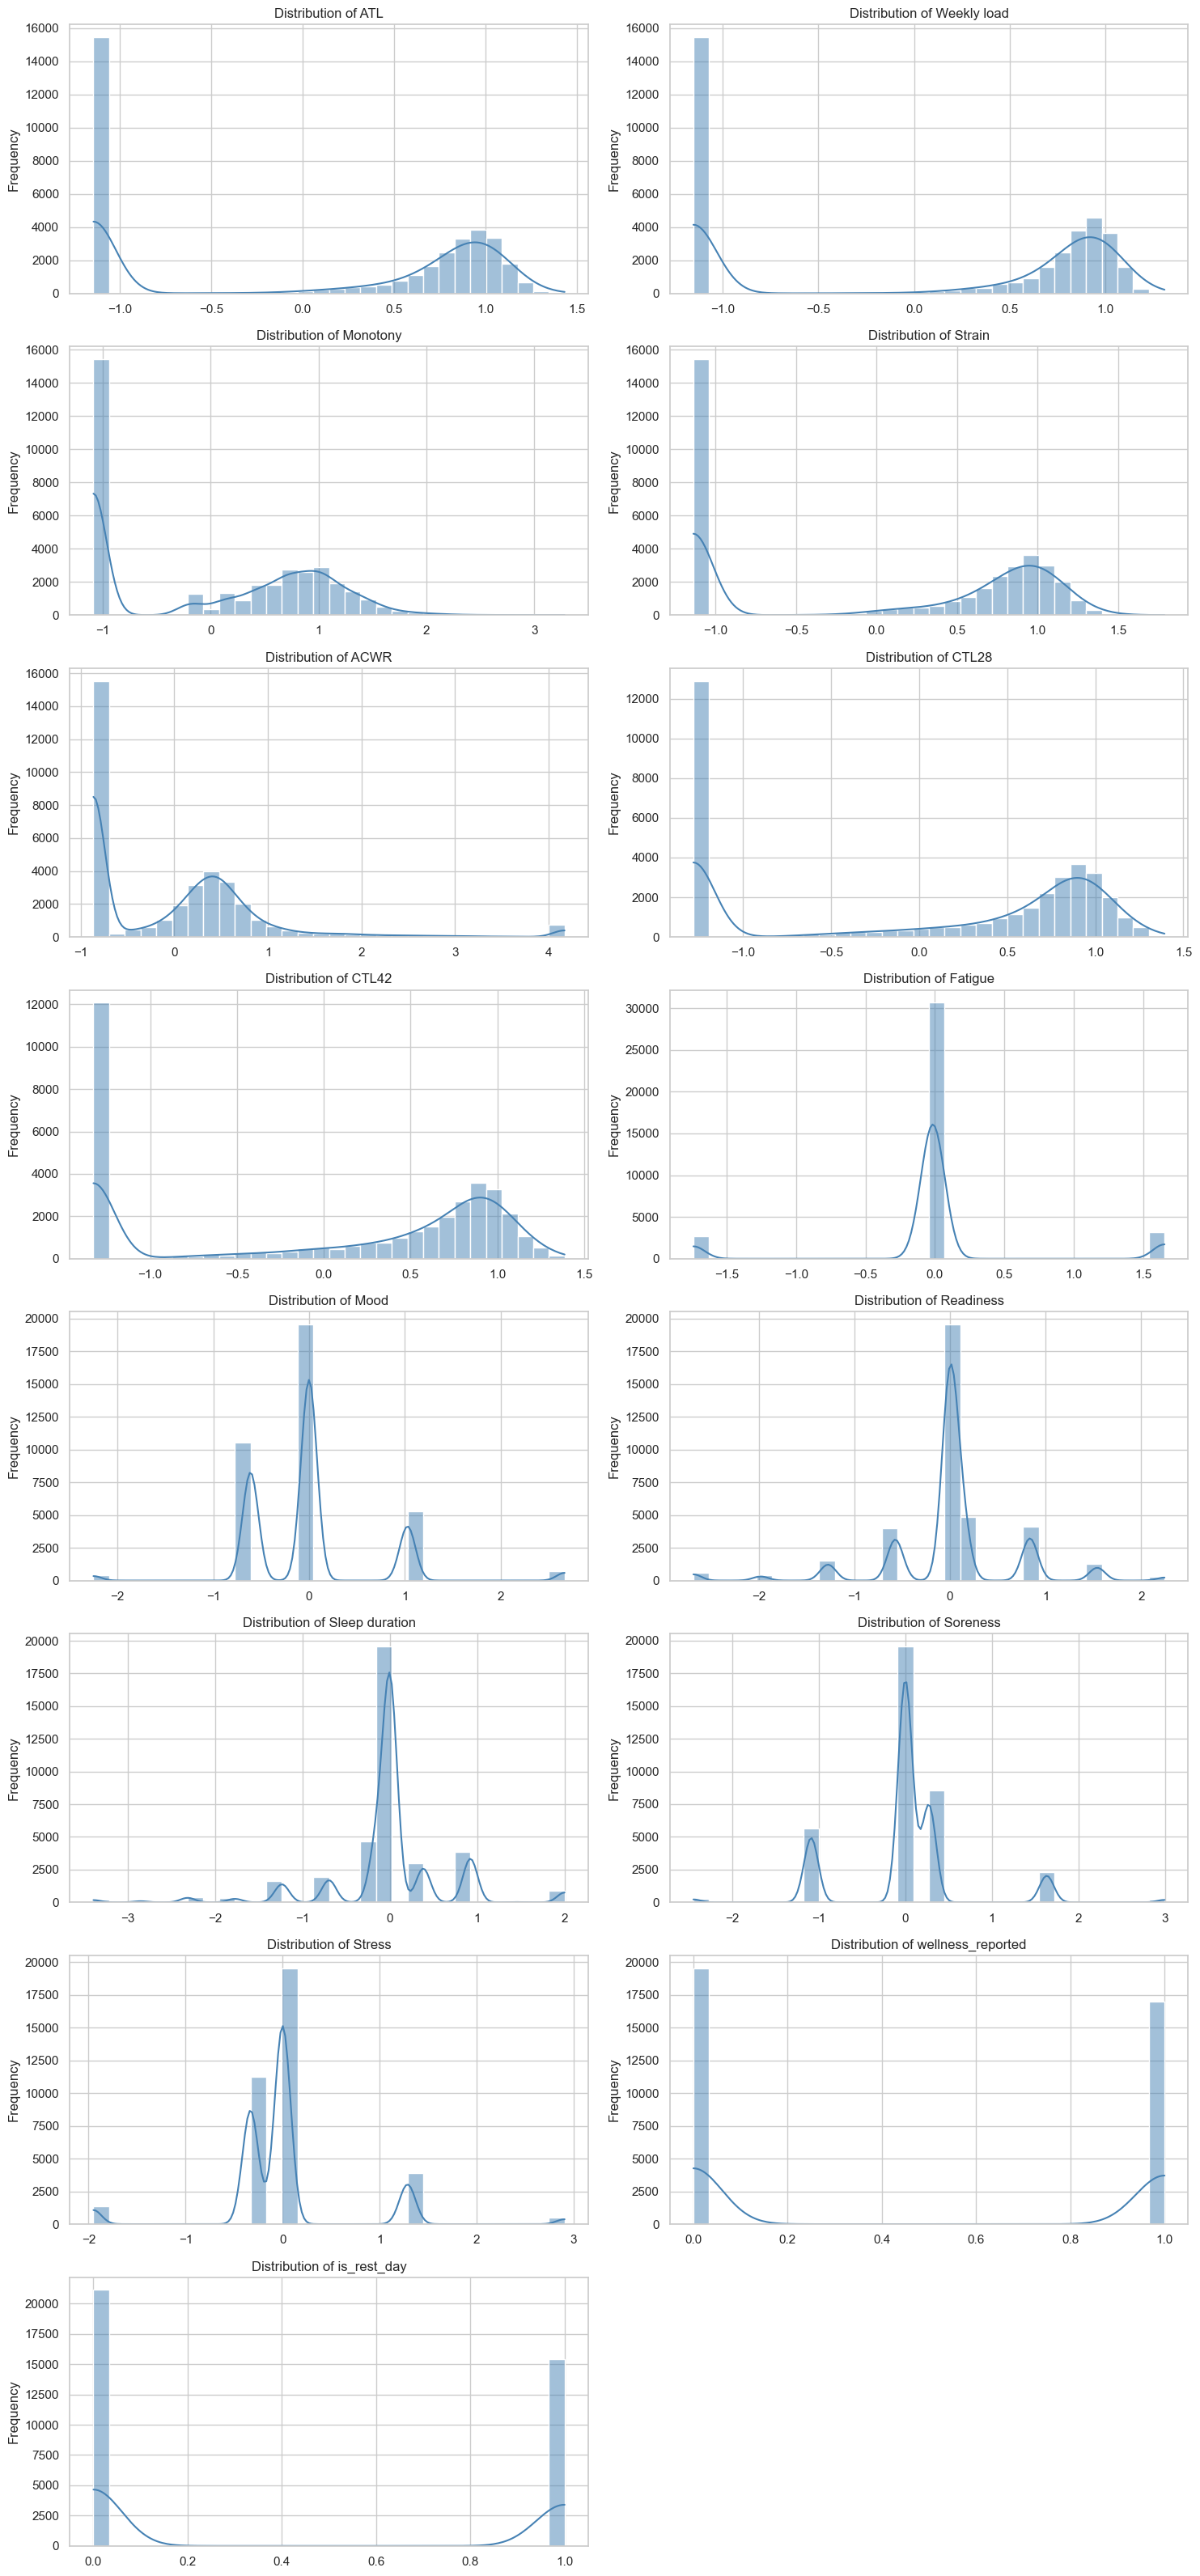

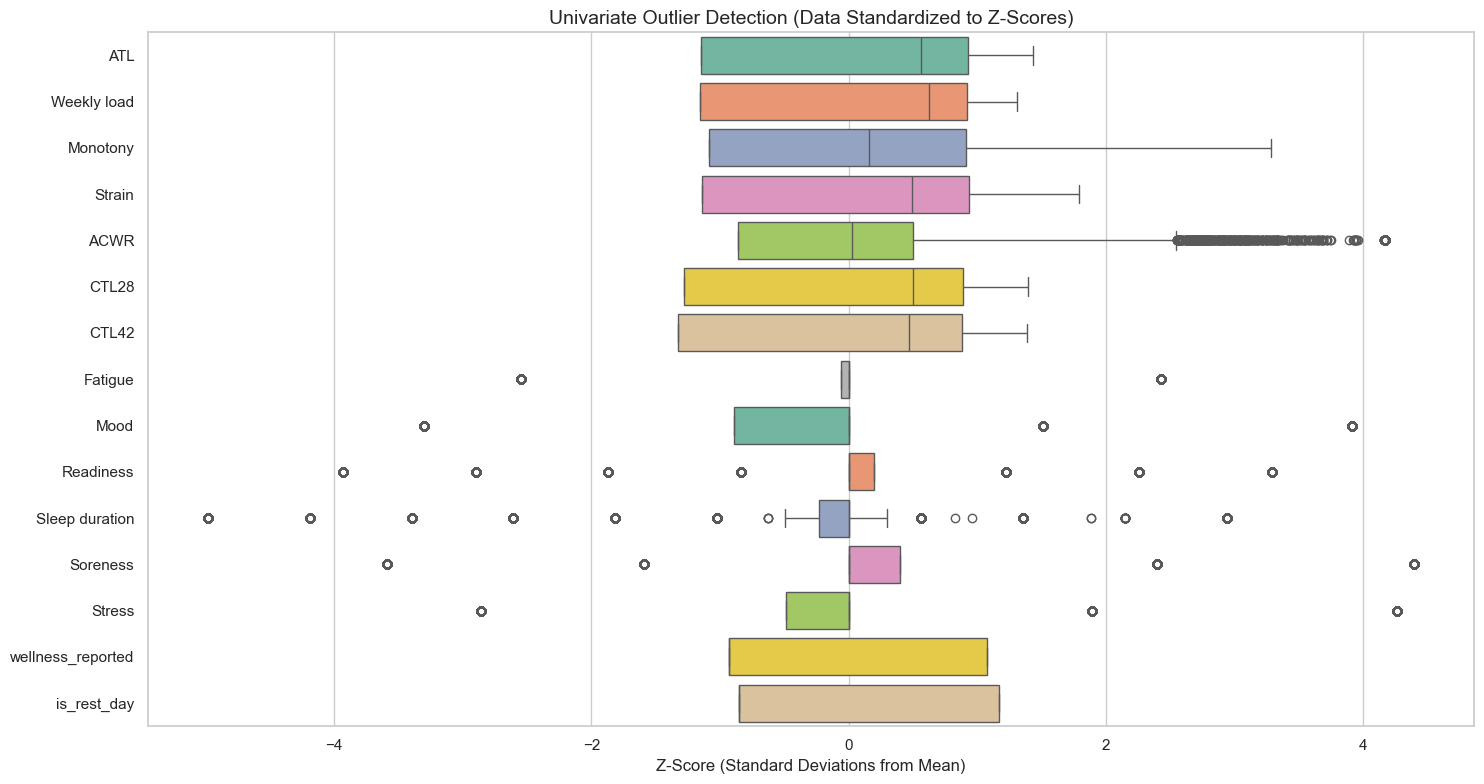

2026-05-17 20:55:38,849 - INFO - Generating correlation matrix...


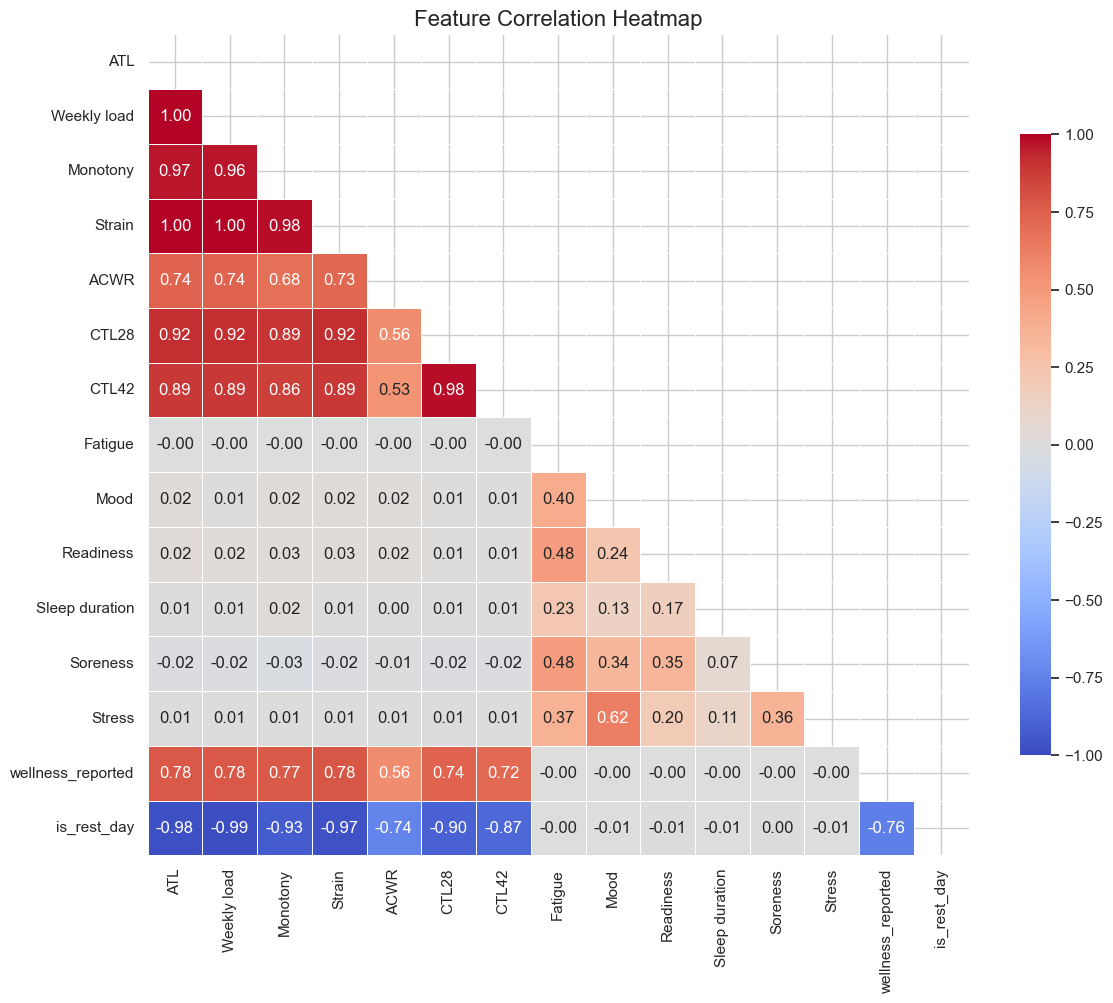

2026-05-17 20:55:39,207 - INFO - Plotting longitudinal trends for ['ATL', 'Readiness', 'Fatigue']...


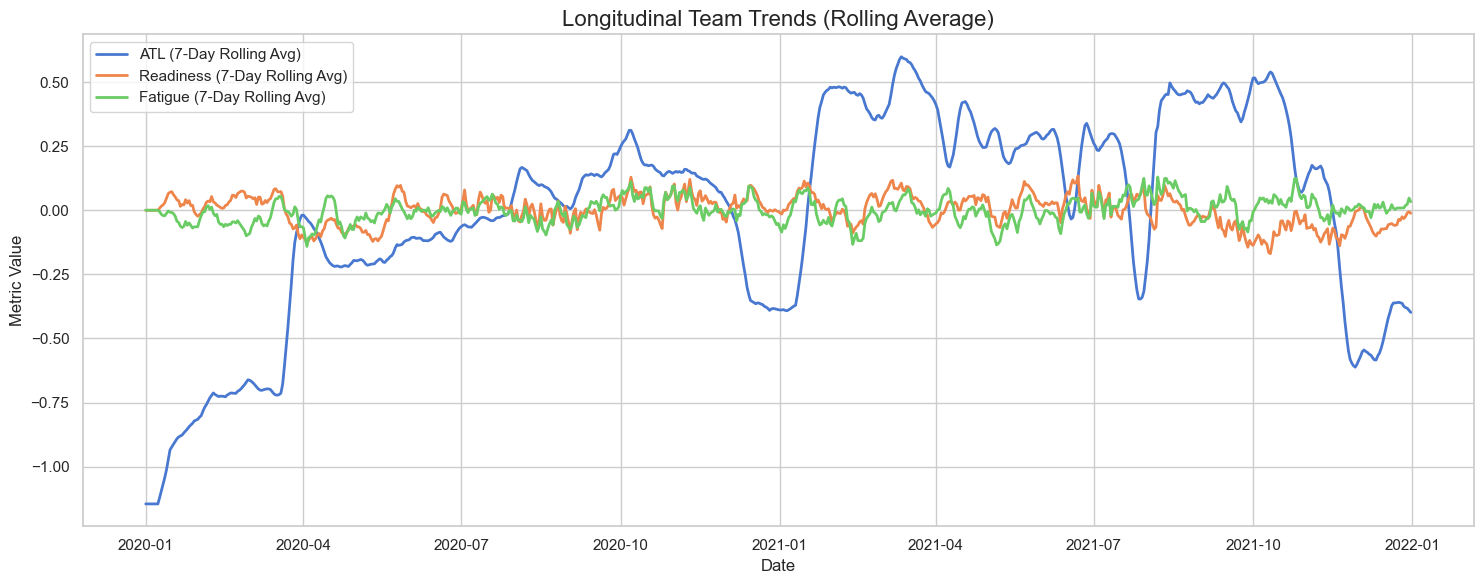

2026-05-17 20:55:39,493 - INFO - Running Isolation Forest for multivariate anomaly detection...
2026-05-17 20:55:40,042 - INFO - Detected 1097 multivariate anomalies.


----------------------------------------
EDA Complete.


In [34]:
# Checkin EDA plots post data processing
eda_pipeline = SubjectiveMetricsEDA(df=deephit_ready_df)
multivariate_anomalies = eda_pipeline.run_all()

In [35]:
# cleaning up environment
del final_df